In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv('data/csvs/examenes.csv')
df = df.sample(n = 100, replace = False)
df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
6823,6824,18,male,ba,2.05,99.4,yes,5.7,average,online videos,high,moderate,72.5
3616,3617,17,other,diploma,1.26,82.4,yes,6.2,average,self-study,high,hard,51.5
13176,13177,23,male,b.sc,1.34,95.2,yes,8.6,poor,group study,medium,moderate,61.0
18411,18412,23,other,b.sc,4.64,44.5,yes,5.7,good,mixed,high,moderate,64.8
3418,3419,17,other,bba,2.31,90.9,yes,5.1,good,mixed,low,moderate,59.3


In [4]:
y_estimados = [1,2,3,4,5,6]
y_reales = [2,4,6,8,10,12]

# y_estimados tiene que tener el mismo tamaño que y_reales

errores = []
for i in range(0,len(y_estimados)):
    errores.append( (y_reales[i] - y_estimados[i]) ** 2)
        
print(errores)

suma = 0
for error in errores:
    suma = suma + error
    print("Valor de suma: ", suma)

[1, 4, 9, 16, 25, 36]
Valor de suma:  1
Valor de suma:  5
Valor de suma:  14
Valor de suma:  30
Valor de suma:  55
Valor de suma:  91


In [5]:
df

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
6823,6824,18,male,ba,2.05,99.4,yes,5.7,average,online videos,high,moderate,72.5
3616,3617,17,other,diploma,1.26,82.4,yes,6.2,average,self-study,high,hard,51.5
13176,13177,23,male,b.sc,1.34,95.2,yes,8.6,poor,group study,medium,moderate,61.0
18411,18412,23,other,b.sc,4.64,44.5,yes,5.7,good,mixed,high,moderate,64.8
3418,3419,17,other,bba,2.31,90.9,yes,5.1,good,mixed,low,moderate,59.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11295,11296,17,other,b.com,0.63,79.9,yes,8.4,poor,online videos,low,moderate,43.8
6282,6283,21,other,bba,0.55,46.8,yes,8.4,good,mixed,high,moderate,53.9
3170,3171,22,male,b.com,6.66,89.5,yes,6.4,average,self-study,medium,moderate,78.2
14690,14691,22,other,b.tech,5.04,43.6,yes,8.6,good,mixed,low,moderate,59.4


ECM:  3686.9189499999998
RECM:  60.720004528985335


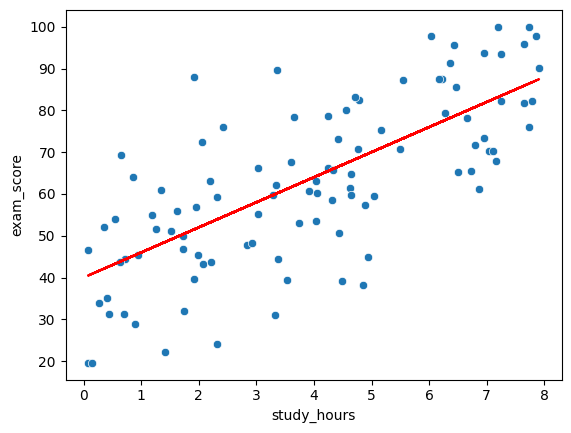

In [6]:
sns.scatterplot(data = df,x = 'study_hours',y = 'exam_score')


def valores_estimados(m,b,x):
    """
    Parametros:
    m -> pendiente de la recta
    b -> ord al origen de la recata
    x -> var independiente
    
    Output:
    y_hat -> valores estimados dado x, m y b
    """
    estimados = []
    for valor_x in x:
        estimados.append(m * valor_x + b)
    return estimados

def error_cuadratico_medio(y_estimados, y_reales):
    y_reales = list(y_reales)
    y_estimados = list(y_estimados)
    errores = []
    for i in range(0,len(y_estimados)):
        errores.append( (y_reales[i] - y_estimados[i]) ** 2)
    
    suma = 0
    for error in errores:
        suma = suma + error
        
    return suma / len(y_estimados) #ECM
    
    

y_estimados = valores_estimados(6, 40, df['study_hours'])
ecm = error_cuadratico_medio(y_estimados, df['study_hours'])
print("ECM: ", ecm)
print("RECM: ", ecm ** 0.5)



plt.plot(
    df["study_hours"],
    y_estimados,
    color =  'red'  
)


-10 5426.983770019998
-9 4787.168112619999
-8 4189.0003712200005
-7 3632.4805458200008
-6 3117.6086364200014
-5 2644.3846430199997
-4 2212.8085656200005
-3 1822.8804042199993
-2 1474.6001588199997
-1 1167.96782942
0 902.9834160200002
1 679.64691862
2 497.95833721999975
3 357.91767181999995
4 259.5249224199999
5 202.78008901999993
6 187.68317162
7 214.23417022000004
8 282.43308482
9 392.27991542
10 543.77466202
11 736.9173246199997
12 971.7079032199998
13 1248.1463978200004
14 1566.2328084199999
15 1925.9671350200003
16 2327.3493776200003
17 2770.3795362199994
18 3255.0576108199994
19 3781.38360142
20 4349.35750802
21 4958.97933062
22 5610.249069219999
23 6303.166723820002
24 7037.732294419998
25 7813.945781019998
26 8631.80718362
27 9491.316502220001
28 10392.473736819997
29 11335.278887419998


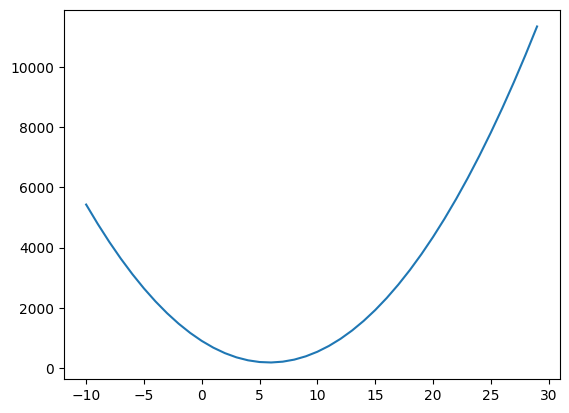

In [7]:
errores_cuadraticos = []
for pendiente in range(-10,30):
    y_estimados = valores_estimados(pendiente, 40,df['study_hours'])
    error_cuadratico_medio_actual = error_cuadratico_medio(y_estimados, df['exam_score'])
    errores_cuadraticos.append(error_cuadratico_medio_actual)
    print(pendiente, error_cuadratico_medio_actual)
    
plt.plot(range(-10,30), errores_cuadraticos)

In [9]:
xi_yi = 0

x = list(df["study_hours"])
y_real = list(df["exam_score"])

for i in range(0, len(x)):
    xi_yi = xi_yi + (x[i] * y_real[i])
    
suma_xi = 0
for valor_x in x:
    suma_xi = suma_xi + valor_x

suma_xi_2 = 0
for valor_x in x:
    suma_xi_2 = suma_xi_2 + (valor_x ** 2)
    
m = (xi_yi - 40 * suma_xi) / suma_xi_2
print(m)

5.862489143514408


In [15]:
lista = [-10,202,43,4,1,2,4,5,6,6,1020,-10]
lista.index(min(lista))

0

In [ ]:
En una lista encontrar la posicion de el elemento mas pequeño sin utilizar index

lista = [2,14,3,512,45,4,6,56,76,7,67]

def encontrar_indice_minimo(lista):
    minimo_act = lista[0]
    for i in range(1,len(lista)):
        if
        
Una funcion que reciba un elemento a buscar y retorne la poscion del elemento en la lista, si no esta retorna -1



In [ ]:
errores = []
pendientes = [valor for valor in range(-10,10)]
ordenadas = [valor for valor in range(20,50)]

for pendiente in pendientes:
    errores_pendiente_act = []
    for b in ordenadas:
        y_estimados = valores_estimados(pendiente, b, x)
        ecm_actual = error_cuadratico_medio(y_estimados, y_real)
        errores_pendiente_act.append(ecm_actual)
        #print(pendiente, b, ecm_actual)
    
    #Acabe de iterar sobre los valores de b
    errores.append(errores_pendiente_act)
    
error_minimo_act = min(errores[0])
min_pendiente = pendientes[0]
minimo_ordenada = ordenadas[errores[0].index(min(errores[0]))]


for fila in range(1, len(pendientes)):
    minimo_fila_actual = min(errores[fila])
    if minimo_fila_actual < error_minimo_act:
        error_minimo_act = minimo_fila_actual
        min_pendiente = pendientes[fila]
        minimo_ordenada = ordenadas[errores[fila].index(min(errores[fila]))]

print(min_pendiente, minimo_ordenada)

for i in range(len(errores)):
    print('\n')
    for j in range(len(errores[0])):
        print(errores[i][j], end = '\t')
        

6 39


8292.26297002	8129.999010020001	7969.735050019999	7811.471090020001	7655.207130020001	7500.943170019998	7348.679210020004	7198.415250019999	7050.1512900200005	6903.887330020001	6759.623370019999	6617.359410020002	6477.09545002	6338.831490020002	6202.56753002	6068.303570019999	5936.039610019999	5805.775650020001	5677.511690020001	5551.24773002	5426.983770019998	5304.71981002	5184.455850020001	5066.19189002	4949.9279300200005	4835.663970019999	4723.400010019999	4613.136050020001	4504.87209002	4398.608130020001	

7495.815312620002	7341.382952620001	7188.950592619996	7038.51823262	6890.085872620002	6743.65351262	6599.22115262	6456.788792620001	6316.3564326199985	6177.924072619998	6041.49171262	5907.059352619998	5774.626992620001	5644.194632619999	5515.7622726200025	5389.329912620002	5264.897552619999	5142.4651926199995	5022.03283262	4903.600472620002	4787.168112619999	4672.735752619999	4560.30339262	4449.87103262	4341.438672620002	4235.006312620001	4130.5739526200005	4028.1415926199